Libraries loaded successfully.
Male   cohort : 5,422
Female cohort : 8,015
Predicted probabilities assigned.
  Male   — mean prob: 0.4100
  Female — mean prob: 0.3503
=== Table 1: Lift Chart — Male ===
  Decile   N  Diabetic  Prevalence  Cum_N  Cum_Diabetic  Cum_Prevalence  Cum_Lift
 Top 10% 542       442      0.8150    542           442          0.8150    2.7190
 Top 20% 542       355      0.6550   1084           797          0.7350    2.4520
 Top 30% 542       309      0.5700   1626          1106          0.6800    2.2680
 Top 40% 542       228      0.4210   2168          1334          0.6150    2.0520
 Top 50% 542       164      0.3030   2710          1498          0.5530    1.8430
 Top 60% 542        91      0.1680   3252          1589          0.4890    1.6290
 Top 70% 542        32      0.0590   3794          1621          0.4270    1.4250
 Top 80% 542         5      0.0090   4336          1626          0.3750    1.2500
 Top 90% 542         0      0.0000   4878          1626     

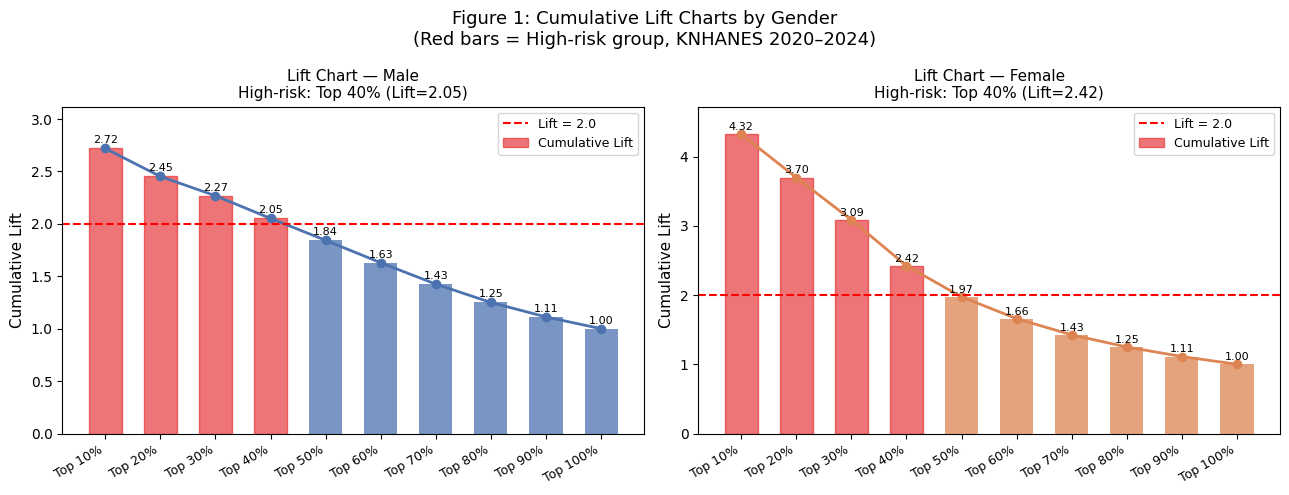

Saved: outputs/fig_lift_charts.png


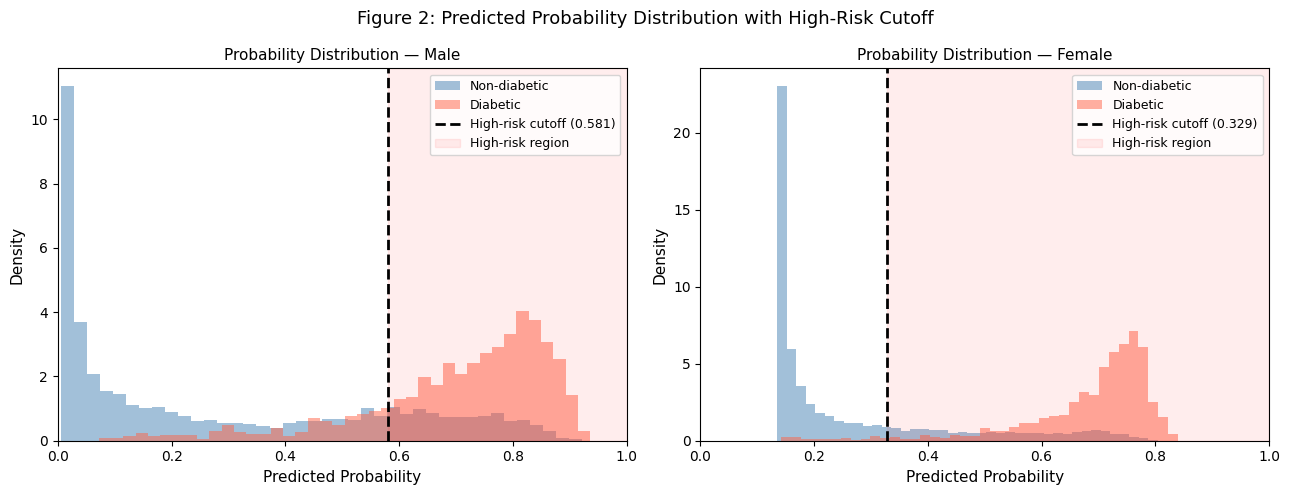

Saved: outputs/fig_prob_distribution.png
=== Table 3a: High-Risk vs Low-Risk — Male ===
Variable        High-risk         Low-risk   t-stat p-value Sig.
  HE_BMI     25.11 ± 2.87     23.67 ± 3.12  17.1870  <0.001  ***
   HE_wc     91.76 ± 7.16     83.72 ± 8.41  36.5140  <0.001  ***
   HE_wt     71.03 ± 9.97    70.82 ± 11.20   0.6920  0.4890   ns
 N_SUGAR    48.48 ± 28.44    60.14 ± 36.93 -12.4500  <0.001  ***
   N_CHO   281.61 ± 88.78   282.14 ± 96.85  -0.2040  0.8380   ns
    N_EN 1889.99 ± 620.42 2076.45 ± 687.06 -10.1720  <0.001  ***
     age     66.21 ± 9.17    41.22 ± 15.27  68.4390  <0.001  ***

=== Table 3b: High-Risk vs Low-Risk — Female ===
Variable        High-risk         Low-risk   t-stat p-value Sig.
  HE_BMI     24.73 ± 3.37     21.81 ± 3.04  40.3020  <0.001  ***
   HE_wc     85.54 ± 8.66     73.73 ± 7.71  63.9410  <0.001  ***
   HE_wt     59.48 ± 9.59     56.54 ± 8.63  14.2570  <0.001  ***
 N_SUGAR    47.91 ± 30.90    55.36 ± 33.58 -10.0480  <0.001  ***
   N_CHO   232.05

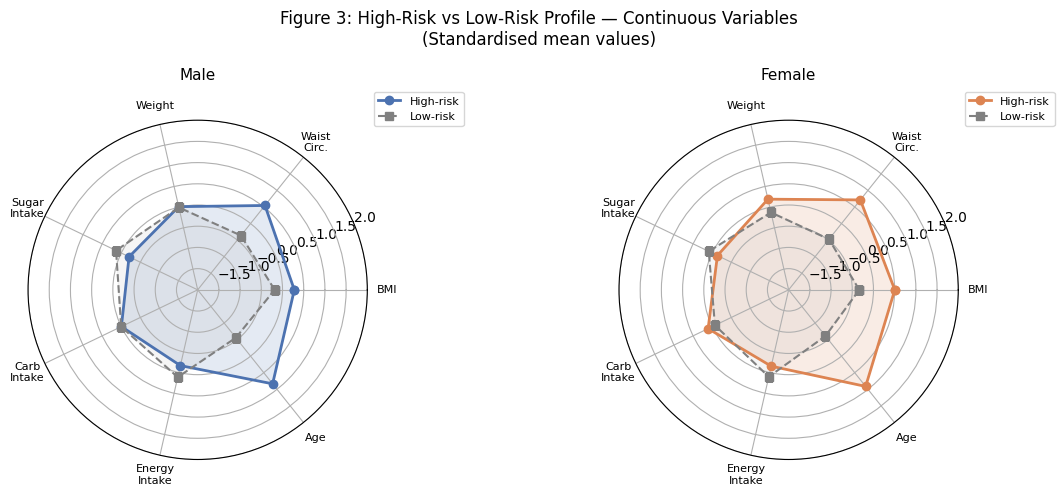

Saved: outputs/fig_highrisk_radar.png
High-risk datasets saved:
  outputs/df_male_highrisk.csv        (2,168 rows)
  outputs/df_female_highrisk.csv      (3,204 rows)
  outputs/df_male_nd_highrisk.csv     (834 rows)  ← DiCE input
  outputs/df_female_nd_highrisk.csv   (1,655 rows)  ← DiCE input

Cutoff metadata saved:
{
  "lift_threshold": 2.0,
  "male": {
    "decile": "Top 40%",
    "cum_lift": 2.052,
    "prob_cutoff": 0.5809654593467712,
    "n_highrisk": 2168,
    "n_nd_highrisk": 834,
    "pct_of_cohort": 40.0
  },
  "female": {
    "decile": "Top 40%",
    "cum_lift": 2.423,
    "prob_cutoff": 0.3285246789455414,
    "n_highrisk": 3204,
    "n_nd_highrisk": 1655,
    "pct_of_cohort": 40.0
  }
}
LIFT CHART & HIGH-RISK GROUP SUMMARY

  [Male]
    Base diabetic rate    : 30.0%
    High-risk threshold   : Cum_Lift >= 2.0
    High-risk boundary    : Top 40%  (Lift=2.052)
    High-risk N           : 2,168  (40% of cohort)
    Non-diabetic high-risk: 834  ← DiCE target

  [Female]
    Ba

In [1]:
# ============================================================
# 06_lift_chart_highrisk.ipynb
# Lift Chart Analysis & High-Risk Group Identification
#
# Paper: A Methodology for Interpretable Health Risk Management:
#        Integrating Counterfactual Explanations and
#        On-Premise Medical LLMs in the Insurance Industry
#
# Contents:
#   1. Lift chart computation (Male / Female)
#   2. High-risk group definition (Cumulative Lift >= 2.0)
#   3. Non-diabetic high-risk group extraction
#      → Input for DiCE counterfactual explanation
#   4. High-risk group descriptive statistics
#   5. Paper-ready figures & tables export
# ============================================================


# ─────────────────────────────────────────────
# Cell 1 | Library Imports
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from scipy import stats
import joblib

pd.set_option('display.float_format', '{:.4f}'.format)
print("Libraries loaded successfully.")


# ─────────────────────────────────────────────
# Cell 2 | Load Data & Pipelines
# ─────────────────────────────────────────────
df_male   = pd.read_csv('outputs/df_male.csv')
df_female = pd.read_csv('outputs/df_female.csv')

pipeline_male   = joblib.load('outputs/models_male/final_pipeline_male.pkl')
pipeline_female = joblib.load('outputs/models_female/final_pipeline_female.pkl')

model_male    = pipeline_male['model']
model_female  = pipeline_female['model']
prep_male     = pipeline_male['preprocessor']
prep_female   = pipeline_female['preprocessor']
thresh_male   = pipeline_male['threshold']
thresh_female = pipeline_female['threshold']
feature_col   = pipeline_male['feature_cols']
target_col    = pipeline_male['target_col']

print(f"Male   cohort : {len(df_male):,}")
print(f"Female cohort : {len(df_female):,}")


# ─────────────────────────────────────────────
# Cell 3 | Generate Predicted Probabilities
#          for FULL datasets (not just test set)
#          → Lift chart uses entire cohort
# ─────────────────────────────────────────────
X_m_all = df_male[feature_col]
X_f_all = df_female[feature_col]

prob_m_all = model_male.predict_proba(
    prep_male.transform(X_m_all)
)[:, 1]
prob_f_all = model_female.predict_proba(
    prep_female.transform(X_f_all)
)[:, 1]

df_male   = df_male.copy()
df_female = df_female.copy()
df_male['pred_prob']   = prob_m_all
df_female['pred_prob'] = prob_f_all

print(f"Predicted probabilities assigned.")
print(f"  Male   — mean prob: {prob_m_all.mean():.4f}")
print(f"  Female — mean prob: {prob_f_all.mean():.4f}")


# ─────────────────────────────────────────────
# Cell 4 | Lift Chart Computation Helper
# ─────────────────────────────────────────────
def compute_lift_chart(df, target, prob_col, n_bins=10):
    """
    Computes decile-based lift chart.

    Returns DataFrame with columns:
      Decile, N, Diabetic, Prevalence,
      Cum_N, Cum_Diabetic, Cum_Prevalence, Cum_Lift
    """
    df_sorted = df.sort_values(prob_col, ascending=False).reset_index(drop=True)
    total_n   = len(df_sorted)
    base_rate = df_sorted[target].mean()
    bin_size  = total_n // n_bins

    rows = []
    for i in range(n_bins):
        start = i * bin_size
        end   = (i + 1) * bin_size if i < n_bins - 1 else total_n
        chunk = df_sorted.iloc[start:end]
        n_chunk   = len(chunk)
        n_diab    = chunk[target].sum()
        prev      = n_diab / n_chunk if n_chunk > 0 else 0

        cum_chunk = df_sorted.iloc[:end]
        cum_n     = len(cum_chunk)
        cum_diab  = cum_chunk[target].sum()
        cum_prev  = cum_diab / cum_n if cum_n > 0 else 0
        cum_lift  = cum_prev / base_rate if base_rate > 0 else 0

        rows.append({
            'Decile'         : f'Top {(i+1)*10}%',
            'N'              : n_chunk,
            'Diabetic'       : int(n_diab),
            'Prevalence'     : round(prev, 3),
            'Cum_N'          : cum_n,
            'Cum_Diabetic'   : int(cum_diab),
            'Cum_Prevalence' : round(cum_prev, 3),
            'Cum_Lift'       : round(cum_lift, 3),
        })
    return pd.DataFrame(rows)


# ─────────────────────────────────────────────
# Cell 5 | Compute Lift Charts
# ─────────────────────────────────────────────
lift_male   = compute_lift_chart(df_male,   target_col, 'pred_prob')
lift_female = compute_lift_chart(df_female, target_col, 'pred_prob')

print("=== Table 1: Lift Chart — Male ===")
print(lift_male.to_string(index=False))

print("\n=== Table 2: Lift Chart — Female ===")
print(lift_female.to_string(index=False))

lift_male.to_csv('outputs/table_lift_male.csv',   index=False)
lift_female.to_csv('outputs/table_lift_female.csv', index=False)
print("\nSaved: outputs/table_lift_male.csv")
print("Saved: outputs/table_lift_female.csv")


# ─────────────────────────────────────────────
# Cell 6 | High-Risk Threshold Identification
#          Rule: first decile where Cum_Lift >= 2.0
# ─────────────────────────────────────────────
LIFT_THRESHOLD = 2.0

def find_highrisk_cutoff(lift_df, lift_col='Cum_Lift', lift_thresh=2.0):
    """
    Returns the last decile row where Cum_Lift >= lift_thresh.
    i.e. the widest high-risk window that still maintains lift >= threshold.
    """
    eligible = lift_df[lift_df[lift_col] >= lift_thresh]
    if eligible.empty:
        print(f"  [Warning] No decile meets Cum_Lift >= {lift_thresh}.")
        return None
    return eligible.iloc[-1]  # last (widest) eligible decile

cutoff_m = find_highrisk_cutoff(lift_male)
cutoff_f = find_highrisk_cutoff(lift_female)

print("=== High-Risk Cutoff Points ===")
print(f"  Male   → {cutoff_m['Decile']}  "
      f"(Cum_Lift={cutoff_m['Cum_Lift']:.3f}, "
      f"N={cutoff_m['Cum_N']:,})")
print(f"  Female → {cutoff_f['Decile']}  "
      f"(Cum_Lift={cutoff_f['Cum_Lift']:.3f}, "
      f"N={cutoff_f['Cum_N']:,})")

# Derive probability cutoff from decile boundary
n_total_m     = len(df_male)
n_total_f     = len(df_female)
pct_m         = cutoff_m['Cum_N'] / n_total_m
pct_f         = cutoff_f['Cum_N'] / n_total_f

prob_cutoff_m = float(
    df_male.sort_values('pred_prob', ascending=False)
    .iloc[cutoff_m['Cum_N'] - 1]['pred_prob']
)
prob_cutoff_f = float(
    df_female.sort_values('pred_prob', ascending=False)
    .iloc[cutoff_f['Cum_N'] - 1]['pred_prob']
)

print(f"\n  Male   prob cutoff : {prob_cutoff_m:.4f}  "
      f"(top {pct_m*100:.0f}% of cohort)")
print(f"  Female prob cutoff : {prob_cutoff_f:.4f}  "
      f"(top {pct_f*100:.0f}% of cohort)")


# ─────────────────────────────────────────────
# Cell 7 | High-Risk Group Extraction
# ─────────────────────────────────────────────
df_male_highrisk   = df_male[df_male['pred_prob'] >= prob_cutoff_m].copy()
df_female_highrisk = df_female[df_female['pred_prob'] >= prob_cutoff_f].copy()

# Non-diabetic high-risk: current label=0 but predicted high-risk
# → Primary target for DiCE counterfactual explanation
df_male_nd_highrisk   = df_male_highrisk[
    df_male_highrisk[target_col] == 0
].copy()
df_female_nd_highrisk = df_female_highrisk[
    df_female_highrisk[target_col] == 0
].copy()

print("=== High-Risk Group Summary ===")
print(f"\n  [Male]")
print(f"    All high-risk        : {len(df_male_highrisk):,}  "
      f"({len(df_male_highrisk)/n_total_m*100:.1f}% of cohort)")
print(f"    Diabetic (known)     : "
      f"{df_male_highrisk[target_col].sum():,}  "
      f"({df_male_highrisk[target_col].mean()*100:.1f}%)")
print(f"    Non-diabetic high-risk: {len(df_male_nd_highrisk):,}  "
      f"← DiCE input")

print(f"\n  [Female]")
print(f"    All high-risk        : {len(df_female_highrisk):,}  "
      f"({len(df_female_highrisk)/n_total_f*100:.1f}% of cohort)")
print(f"    Diabetic (known)     : "
      f"{df_female_highrisk[target_col].sum():,}  "
      f"({df_female_highrisk[target_col].mean()*100:.1f}%)")
print(f"    Non-diabetic high-risk: {len(df_female_nd_highrisk):,}  "
      f"← DiCE input")


# ─────────────────────────────────────────────
# Cell 8 | Figure 1 — Lift Charts (Male & Female)
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (lift_df, cutoff, label, color) in zip(axes, [
    (lift_male,   cutoff_m, 'Male',   '#4C72B0'),
    (lift_female, cutoff_f, 'Female', '#DD8452'),
]):
    x     = np.arange(len(lift_df))
    bars  = ax.bar(x, lift_df['Cum_Lift'], color=color,
                   alpha=0.75, width=0.6, label='Cumulative Lift')
    ax.plot(x, lift_df['Cum_Lift'], 'o-', color=color,
            lw=2, markersize=6)

    # Threshold line
    ax.axhline(y=LIFT_THRESHOLD, color='red', linestyle='--',
               lw=1.5, label=f'Lift = {LIFT_THRESHOLD}')

    # Shade high-risk region
    cutoff_idx = lift_df[lift_df['Decile'] == cutoff['Decile']].index[0]
    for j in range(cutoff_idx + 1):
        bars[j].set_color('#e41a1c')
        bars[j].set_alpha(0.6)

    # Annotate lift values
    for j, val in enumerate(lift_df['Cum_Lift']):
        ax.text(j, val + 0.03, f'{val:.2f}',
                ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(lift_df['Decile'], rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('Cumulative Lift', fontsize=11)
    ax.set_title(f'Lift Chart — {label}\n'
                 f'High-risk: {cutoff["Decile"]} '
                 f'(Lift={cutoff["Cum_Lift"]:.2f})', fontsize=11)
    ax.legend(fontsize=9)
    ax.set_ylim([0, lift_df['Cum_Lift'].max() + 0.4])

fig.suptitle('Figure 1: Cumulative Lift Charts by Gender\n'
             '(Red bars = High-risk group, KNHANES 2020–2024)',
             fontsize=13)
plt.tight_layout()
plt.savefig('outputs/fig_lift_charts.png', bbox_inches='tight')
plt.show()
print("Saved: outputs/fig_lift_charts.png")


# ─────────────────────────────────────────────
# Cell 9 | Figure 2 — Predicted Probability
#          Distribution with High-Risk Cutoff
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (df_g, cutoff_prob, label, color) in zip(axes, [
    (df_male,   prob_cutoff_m, 'Male',   '#4C72B0'),
    (df_female, prob_cutoff_f, 'Female', '#DD8452'),
]):
    non_d  = df_g[df_g[target_col] == 0]['pred_prob']
    diab   = df_g[df_g[target_col] == 1]['pred_prob']

    ax.hist(non_d, bins=40, alpha=0.5, color='steelblue',
            label='Non-diabetic', density=True)
    ax.hist(diab,  bins=40, alpha=0.5, color='tomato',
            label='Diabetic',     density=True)
    ax.axvline(x=cutoff_prob, color='black', linestyle='--',
               lw=2, label=f'High-risk cutoff ({cutoff_prob:.3f})')
    ax.axvspan(cutoff_prob, 1.0, alpha=0.07, color='red',
               label='High-risk region')

    ax.set_xlabel('Predicted Probability', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(f'Probability Distribution — {label}', fontsize=11)
    ax.legend(fontsize=9)
    ax.set_xlim([0, 1])

fig.suptitle('Figure 2: Predicted Probability Distribution with High-Risk Cutoff',
             fontsize=13)
plt.tight_layout()
plt.savefig('outputs/fig_prob_distribution.png', bbox_inches='tight')
plt.show()
print("Saved: outputs/fig_prob_distribution.png")


# ─────────────────────────────────────────────
# Cell 10 | Table 3 — Descriptive Statistics
#           High-Risk vs Low-Risk Group
# ─────────────────────────────────────────────
num_col = pipeline_male['num_col']

def desc_compare(df, group_col, num_vars):
    """Compare continuous variables between high/low risk groups."""
    rows = []
    for col in num_vars:
        hi  = df[df[group_col] == 1][col]
        lo  = df[df[group_col] == 0][col]
        t, p = stats.ttest_ind(hi, lo)
        sig  = '***' if p < 0.001 else ('**' if p < 0.01 else
               ('*' if p < 0.05 else 'ns'))
        rows.append({
            'Variable'   : col,
            'High-risk'  : f"{hi.mean():.2f} ± {hi.std():.2f}",
            'Low-risk'   : f"{lo.mean():.2f} ± {lo.std():.2f}",
            't-stat'     : round(t, 3),
            'p-value'    : '<0.001' if p < 0.001 else round(p, 3),
            'Sig.'       : sig,
        })
    return pd.DataFrame(rows)

# Add is_highrisk flag
df_male['is_highrisk']   = (
    df_male['pred_prob'] >= prob_cutoff_m
).astype(int)
df_female['is_highrisk'] = (
    df_female['pred_prob'] >= prob_cutoff_f
).astype(int)

desc_m = desc_compare(df_male,   'is_highrisk', num_col)
desc_f = desc_compare(df_female, 'is_highrisk', num_col)

print("=== Table 3a: High-Risk vs Low-Risk — Male ===")
print(desc_m.to_string(index=False))

print("\n=== Table 3b: High-Risk vs Low-Risk — Female ===")
print(desc_f.to_string(index=False))

desc_m.to_csv('outputs/table_highrisk_desc_male.csv',   index=False)
desc_f.to_csv('outputs/table_highrisk_desc_female.csv', index=False)
print("\nSaved: outputs/table_highrisk_desc_male.csv")
print("Saved: outputs/table_highrisk_desc_female.csv")


# ─────────────────────────────────────────────
# Cell 11 | Figure 3 — High-Risk Group Profile
#           Radar Chart (Mean values, standardised)
# ─────────────────────────────────────────────
from matplotlib.patches import FancyArrowPatch

def radar_chart(ax, values_hi, values_lo, labels, title, color):
    N      = len(labels)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    v_hi = values_hi + values_hi[:1]
    v_lo = values_lo + values_lo[:1]

    ax.plot(angles, v_hi, 'o-', color=color,     lw=2,   label='High-risk')
    ax.fill(angles, v_hi, alpha=0.15, color=color)
    ax.plot(angles, v_lo, 's--', color='gray',   lw=1.5, label='Low-risk')
    ax.fill(angles, v_lo, alpha=0.08, color='gray')

    ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=8)
    ax.set_ylim([-2, 2])
    ax.set_title(title, size=11, pad=15)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=8)

# Standardise continuous variables for radar
scaler_m = dict(zip(num_col, [
    (df_male[c].mean(), df_male[c].std()) for c in num_col
]))

def standardise(df, col_stats):
    return [
        (df[df['is_highrisk']==1][c].mean() - mu) / (sd + 1e-10)
        for c, (mu, sd) in col_stats.items()
    ], [
        (df[df['is_highrisk']==0][c].mean() - mu) / (sd + 1e-10)
        for c, (mu, sd) in col_stats.items()
    ]

radar_labels = ['BMI','Waist\nCirc.','Weight',
                'Sugar\nIntake','Carb\nIntake',
                'Energy\nIntake','Age']

scaler_f = dict(zip(num_col, [
    (df_female[c].mean(), df_female[c].std()) for c in num_col
]))

hi_m, lo_m = standardise(df_male,   scaler_m)
hi_f, lo_f = standardise(df_female, scaler_f)

fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(121, polar=True)
ax2 = fig.add_subplot(122, polar=True)

radar_chart(ax1, hi_m, lo_m, radar_labels, 'Male',   '#4C72B0')
radar_chart(ax2, hi_f, lo_f, radar_labels, 'Female', '#DD8452')

fig.suptitle('Figure 3: High-Risk vs Low-Risk Profile — Continuous Variables\n'
             '(Standardised mean values)', fontsize=12)
plt.tight_layout()
plt.savefig('outputs/fig_highrisk_radar.png', bbox_inches='tight')
plt.show()
print("Saved: outputs/fig_highrisk_radar.png")


# ─────────────────────────────────────────────
# Cell 12 | Save High-Risk Datasets
#           (Full high-risk + Non-diabetic high-risk)
# ─────────────────────────────────────────────
# Full high-risk
df_male_highrisk.to_csv(
    'outputs/df_male_highrisk.csv', index=False
)
df_female_highrisk.to_csv(
    'outputs/df_female_highrisk.csv', index=False
)

# Non-diabetic high-risk → DiCE input
df_male_nd_highrisk.to_csv(
    'outputs/df_male_nd_highrisk.csv', index=False
)
df_female_nd_highrisk.to_csv(
    'outputs/df_female_nd_highrisk.csv', index=False
)

print("High-risk datasets saved:")
print(f"  outputs/df_male_highrisk.csv        "
      f"({len(df_male_highrisk):,} rows)")
print(f"  outputs/df_female_highrisk.csv      "
      f"({len(df_female_highrisk):,} rows)")
print(f"  outputs/df_male_nd_highrisk.csv     "
      f"({len(df_male_nd_highrisk):,} rows)  ← DiCE input")
print(f"  outputs/df_female_nd_highrisk.csv   "
      f"({len(df_female_nd_highrisk):,} rows)  ← DiCE input")


# ─────────────────────────────────────────────
# Cell 13 | Save Cutoff Metadata
#           (Used by DiCE notebooks 07 & 08)
# ─────────────────────────────────────────────
import json

cutoff_meta = {
    'lift_threshold'   : LIFT_THRESHOLD,
    'male': {
        'decile'          : cutoff_m['Decile'],
        'cum_lift'        : float(cutoff_m['Cum_Lift']),
        'prob_cutoff'     : float(prob_cutoff_m),
        'n_highrisk'      : int(len(df_male_highrisk)),
        'n_nd_highrisk'   : int(len(df_male_nd_highrisk)),
        'pct_of_cohort'   : round(pct_m * 100, 1),
    },
    'female': {
        'decile'          : cutoff_f['Decile'],
        'cum_lift'        : float(cutoff_f['Cum_Lift']),
        'prob_cutoff'     : float(prob_cutoff_f),
        'n_highrisk'      : int(len(df_female_highrisk)),
        'n_nd_highrisk'   : int(len(df_female_nd_highrisk)),
        'pct_of_cohort'   : round(pct_f * 100, 1),
    },
}

with open('outputs/highrisk_cutoff_meta.json', 'w') as f:
    json.dump(cutoff_meta, f, indent=2)

print("\nCutoff metadata saved:")
print(json.dumps(cutoff_meta, indent=2))


# ─────────────────────────────────────────────
# Cell 14 | Summary Report
# ─────────────────────────────────────────────
print("=" * 65)
print("LIFT CHART & HIGH-RISK GROUP SUMMARY")
print("=" * 65)

for label, lift_df, cutoff, n_hi, n_nd, pct in [
    ('Male',   lift_male,   cutoff_m,
     len(df_male_highrisk),   len(df_male_nd_highrisk),   pct_m),
    ('Female', lift_female, cutoff_f,
     len(df_female_highrisk), len(df_female_nd_highrisk), pct_f),
]:
    base = lift_df.iloc[-1]['Cum_Prevalence']
    print(f"\n  [{label}]")
    print(f"    Base diabetic rate    : {base*100:.1f}%")
    print(f"    High-risk threshold   : Cum_Lift >= {LIFT_THRESHOLD}")
    print(f"    High-risk boundary    : {cutoff['Decile']}  "
          f"(Lift={cutoff['Cum_Lift']:.3f})")
    print(f"    High-risk N           : {n_hi:,}  ({pct*100:.0f}% of cohort)")
    print(f"    Non-diabetic high-risk: {n_nd:,}  ← DiCE target")

print(f"\n[Methodological Note]")
print(f"  Lift >= 2.0 criterion is exploratory.")
print(f"  In real-world deployment, cutoff should be validated")
print(f"  against clinical guidelines (e.g. HbA1c >= 5.7%,")
print(f"  ADA prediabetes criteria) and cost-benefit analysis.")

print(f"\n{'='*65}")
print("Proceed to 07_dice_counterfactual_male.ipynb")